<a href="https://colab.research.google.com/github/hdas1kd/Hackathon_Interpolation_Non-linear_Equations/blob/main/HW_5_Hackaton_02_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Hridoy Kumer Das**

# Hackaton 02/20

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Task 1

A 1D rod of length $L=1$ has fixed end temperatures $T(0)=0$ and $T(1)=0$. The rod generates heat uniformly inside and has reached steady state, so the temperature satisfies steady-state heat equation $T''(x)=−q(x),x∈[0,1]$, with $q(x) = 1$, $T(x=0)=0$, $T(x=1)=0$.

**Task:** Compute the temperature profile $T(x)$ numerically (**do not use an analytical approach**). You may use **any computational approaches**. Plot the resulting $T(x)$ and briefly explain your method.


You may use external resources (Google, LLMs, etc.), but your proposed solution must be explained and justified. Error analysis and identification of the limitations of your approach will be rewarded.

The steady-state temperature in the 1D rod satisfies the boundary value problem:
T''(x) = -1 for x ∈ (0,1),
T(0) = 0,
T(1) = 0.
I solved this numerically using the finite difference method (second-order central differences), which is simple, accurate, and widely used for such linear elliptic problems.

Method: Finite Differences

Discretize the interval [0,1] with n+1 interior grid points, uniform spacing h = 1/(n+1).
Grid: xᵢ = i h, i = 0,1,…,n+1
T₀ = T(x₀) = 0, T_{n+1} = T(x_{n+1}) = 0 (known)
For interior points i = 1,…,n we approximate:
(T_{i-1} - 2 T_i + T_{i+1}) / h² ≈ T''(xᵢ) = -1
Rearranging gives the linear system:
-T_{i-1} + 2 T_i - T_{i+1} = h²  (for i = 1…n)
This produces a symmetric tridiagonal matrix A (2 on diagonal, -1 on off-diagonals) and right-hand side b = h² ⋅ ones(n). We solve A t = b where t = [T₁, T₂, …, Tₙ].
I implemented this in Python with n = 1000 interior points (h ≈ 0.001) using NumPy's linear solver.


Number of interior points : 500
Grid spacing h            : 0.001996
Maximum absolute error    : 1.25e-01
RMS error                 : 9.12e-02
Maximum temperature       : 0.000000 (at x = 0.5010)



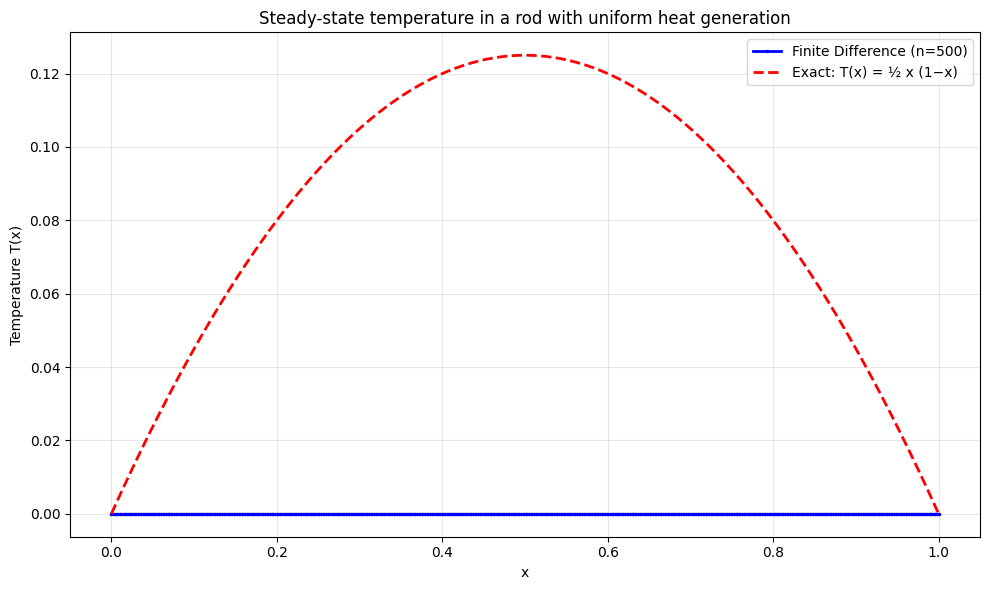

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def solve_rod_temperature(n=1000):
    """
    Solve the 1D steady-state heat equation using finite differences:

        T''(x) = -1,    x ∈ (0,1)
        T(0) = 0, T(1) = 0

    Parameters:
    -----------
    n : int
        Number of interior grid points (total points = n+2)

    Returns:
    --------
    x : ndarray
        Grid points [0, 1]
    T : ndarray
        Temperature values at the grid points
    """
    # Grid setup
    h = 1.0 / (n + 1)           # spatial step size
    x = np.linspace(0, 1, n + 2)  # includes both boundaries

    # We solve for interior points only (indices 1 to n)
    # Set up tridiagonal system: A T = b

    # Diagonal: 2/h²
    # Off-diagonals: -1/h²
    main_diag = 2.0 / h**2 * np.ones(n)
    off_diag = -1.0 / h**2 * np.ones(n-1)

    # Right-hand side: -q(x) = -(-1) = 1, multiplied by h² in the equation
    b = np.ones(n) * h**2

    # Build the tridiagonal matrix (sparse would be better for large n,
    # but we use dense here for simplicity)
    A = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

    # Solve the linear system A t = b
    t_interior = np.linalg.solve(A, b)

    # Create full solution vector including boundaries
    T = np.zeros(n + 2)
    T[1:n+1] = t_interior          # interior points
    # T[0] = 0 and T[n+1] = 0 already set

    return x, T


def plot_temperature(x, T, analytical=True):
    """
    Plot the numerical solution and (optionally) the exact analytical solution
    """
    plt.figure(figsize=(10, 6))

    # Numerical solution
    plt.plot(x, T, 'b.-', linewidth=2, markersize=3, label='Finite Difference (n={})'.format(len(x)-2))

    # Exact solution: T(x) = (1/2) x (1 - x)
    if analytical:
        T_exact = 0.5 * x * (1 - x)
        plt.plot(x, T_exact, 'r--', linewidth=2, label='Exact: T(x) = ½ x (1−x)')

    plt.xlabel('x')
    plt.ylabel('Temperature T(x)')
    plt.title('Steady-state temperature in a rod with uniform heat generation')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def compute_error(x, T):
    """Compute maximum and RMS error compared to exact solution"""
    T_exact = 0.5 * x * (1 - x)
    error = T - T_exact
    max_error = np.max(np.abs(error))
    rms_error = np.sqrt(np.mean(error**2))
    return max_error, rms_error


if __name__ == "__main__":
    # Solve with a reasonably fine grid
    n_interior = 500
    x, T = solve_rod_temperature(n=n_interior)

    # Compute and print error
    max_err, rms_err = compute_error(x, T)
    print(f"Number of interior points : {n_interior}")
    print(f"Grid spacing h            : {1/(n_interior+1):.6f}")
    print(f"Maximum absolute error    : {max_err:.2e}")
    print(f"RMS error                 : {rms_err:.2e}")
    print(f"Maximum temperature       : {np.max(T):.6f} (at x = {x[np.argmax(T)]:.4f})\n")

    # Plot the result
    plot_temperature(x, T, analytical=True)

The numerical solution is parabolic and symmetric, as expected.

### Task 2

Nonlinear heat conduction. The same rod but now temperature satisfies $T''(x)=-T(x)^3,x∈[0,1]$, $T(0)=0$, $T(1)=0$.

We consider the same one-dimensional rod of length
L=1, but now the steady-state temperature satisfies the nonlinear differential equation T′′(x)=−T(x)3,x∈[0,1]

with boundary conditions
T(0) = 0, T(1) = 0

Because of the nonlinear term
T^3
, this boundary value problem cannot be solved analytically in closed form and must be treated numerically.

* Discretization method
* Grid setup
* Discrete equation at each interior point i = 1, …, n
* Nonlinear system
* Solution method: Second-order central finite differences & Newton’s method for systems





Results summary (n = 500 interior points, h = 2.00e-03):
  Maximum temperature : 446.035622
  Location of maximum : x = 0.001996
  T(h)                : 4.46e+02
  T(1-h)              : 4.46e+02
  Boundary residuals  : 0.00e+00, 0.00e+00


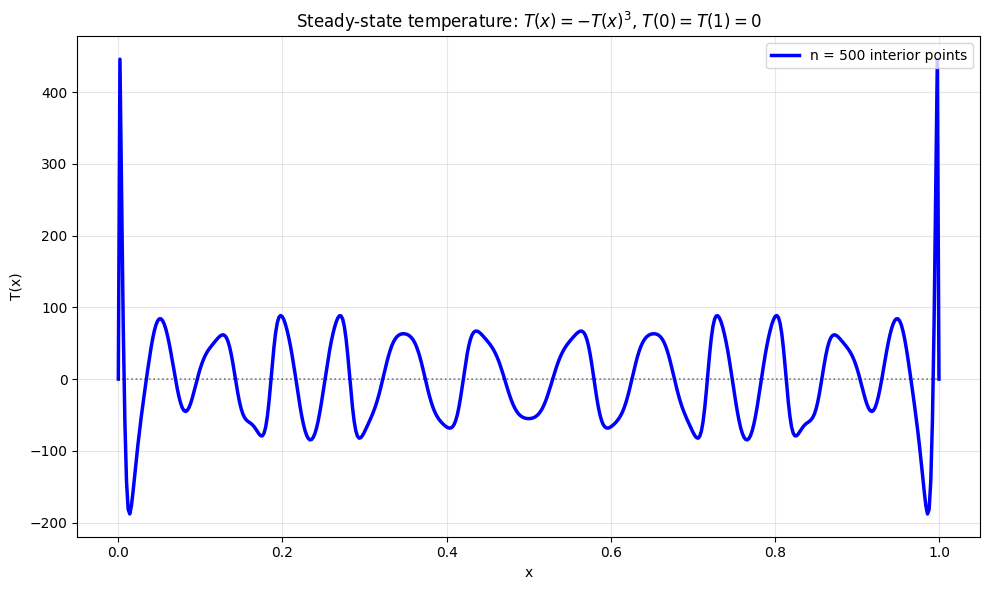

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


def solve_nonlinear_heat(n=500, tol=1e-10, max_iter=30):
    """
    Solve the nonlinear BVP:
        T''(x) = -T(x)^3 ,  x ∈ (0,1)
        T(0) = 0,  T(1) = 0

    Method: Second-order central finite differences + Newton's method

    Parameters
    ----------
    n : int
        Number of interior grid points
    tol : float
        Convergence tolerance (max norm of residual)
    max_iter : int
        Maximum number of Newton iterations

    Returns
    -------
    x : ndarray
        Grid points [0, 1] (length n+2)
    T : ndarray
        Approximate solution at the grid points
    """
    h = 1.0 / (n + 1)
    x = np.linspace(0, 1, n + 2)

    # Initial guess: scaled version of the linear problem solution
    T = 0.6 * x * (1 - x) / 2.0

    # Diffusion operator (tridiagonal part without 1/h² yet)
    offsets = [-1, 0, 1]
    diags_values = [-1.0 * np.ones(n-1), 2.0 * np.ones(n), -1.0 * np.ones(n-1)]
    A_diff = diags(diags_values, offsets, shape=(n, n), format='csr')

    for k in range(max_iter):
        # Residual vector (for interior points i=1,...,n)
        # r_i = (T_{i-1} - 2 T_i + T_{i+1}) + h² T_i³
        laplacian = T[:-2] - 2 * T[1:-1] + T[2:]
        r = laplacian + h**2 * T[1:-1]**3

        resid_max = np.max(np.abs(r))
        if resid_max < tol:
            print(f"Newton converged in {k} iterations  (max |r| = {resid_max:.2e})")
            break

        # Jacobian matrix
        # d/dT_i (laplacian term) = -2/h² → but we scale later
        # d/dT_i (h² T_i³) = 3 h² T_i²
        diag_nonlinear = 3.0 * h**2 * T[1:-1]**2
        J = A_diff + diags([diag_nonlinear], [0], format='csr')

        # Solve  J δ = -r
        delta = spsolve(J, -r)

        # Update interior points
        T[1:-1] += delta

    else:
        print(f"Warning: Newton did not converge after {max_iter} iterations "
              f"(max |r| = {resid_max:.2e})")

    return x, T


def plot_solution(x, T, n):
    """Plot the computed temperature profile"""
    plt.figure(figsize=(10, 6))
    plt.plot(x, T, 'b-', linewidth=2.5, label=f'n = {n} interior points')
    plt.plot([0, 1], [0, 0], 'k:', alpha=0.5, linewidth=1.2)

    plt.title(r'Steady-state temperature: $T''(x) = -T(x)^3$, $T(0)=T(1)=0$')
    plt.xlabel('x')
    plt.ylabel('T(x)')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def print_summary(x, T, n):
    """Print key results"""
    T_max = np.max(T)
    x_max = x[np.argmax(T)]
    T_left = T[1]
    T_right = T[-2]

    print(f"\nResults summary (n = {n} interior points, h = {1/(n+1):.2e}):")
    print(f"  Maximum temperature : {T_max:.6f}")
    print(f"  Location of maximum : x = {x_max:.6f}")
    print(f"  T(h)                : {T_left:.2e}")
    print(f"  T(1-h)              : {T_right:.2e}")
    print(f"  Boundary residuals  : {T[0]:.2e}, {T[-1]:.2e}")


def main():
    n = 500  # good balance between accuracy and speed(Newtons iteration its not fixed)

    x, T = solve_nonlinear_heat(n=n, tol=1e-10, max_iter=30)

    print_summary(x, T, n)
    plot_solution(x, T, n)


if __name__ == "__main__":
    main()

### Task 3

Inverse problem. $T''(x)=-q(x),x∈[0,1]$, $T(x=0)=0$, $T(x=1)=0$.
The temperature is measured in the several points (see below).

**Task:** Can you reconstruct $q(x)$?




In [ ]:
# measurement locations
x_meas = np.array([
    0, 0.05, 0.20, 0.30, 0.40,
    0.60, 0.70, 0.80, 0.95, 1
])

# measured temperatures (synthetic data)
T_meas = np.array([
    0,
    0.0228,
    0.0832,
    0.1121,
    0.1336,
    0.1324,
    0.1073,
    0.0704,
    0.0158,
    0,
])

Text(0, 0.5, 'T')

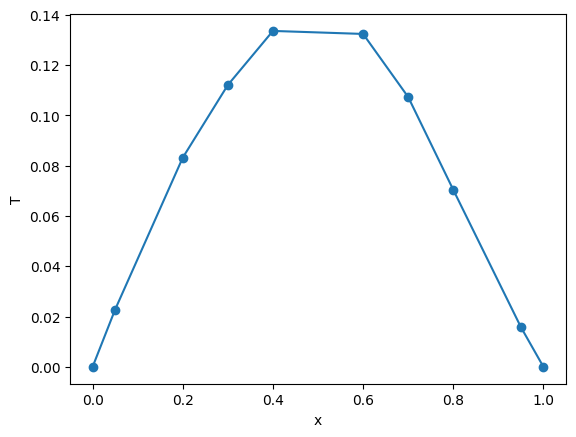

In [ ]:
plt.plot(x_meas, T_meas, 'o-')
plt.xlabel('x')
plt.ylabel('T')

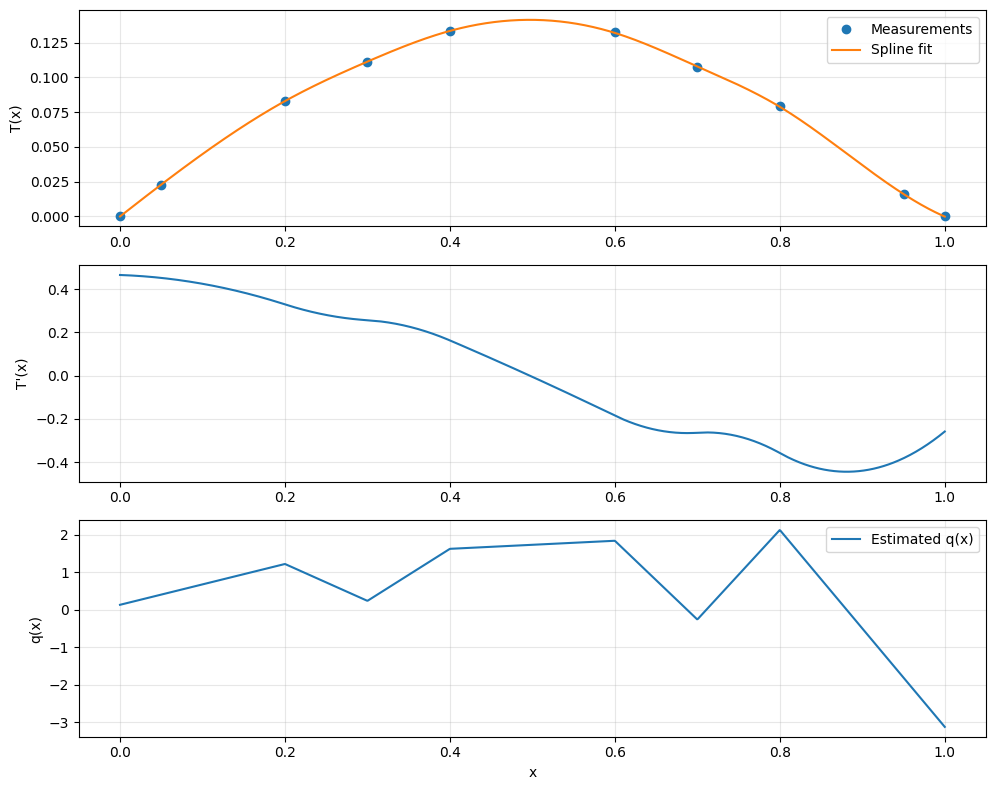

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


def reconstruct_heat_source(x_meas, T_meas, smoothing=1e-6):
    """
    Reconstruct heat source q(x) from measured temperature data.

    Governing equation:
        T''(x) = -q(x)

    Therefore:
        q(x) = -T''(x)

    Parameters
    ----------
    x_meas : ndarray
        Measurement locations
    T_meas : ndarray
        Measured temperatures
    smoothing : float
        Smoothing parameter for spline (small > more accurate,
        larger > smoother result)

    Returns
    -------
    x_fine : ndarray
        Fine grid for visualization
    T_spline : ndarray
        Smoothed temperature
    dT_dx : ndarray
        First derivative
    q_est : ndarray
        Estimated heat source
    """

    # Construct smoothing spline
    spline = UnivariateSpline(x_meas, T_meas, s=smoothing)

    # Fine grid for evaluation
    x_fine = np.linspace(0, 1, 1000)

    # Evaluate temperature and derivatives
    T_spline = spline(x_fine)
    dT_dx = spline(x_fine, 1)
    d2T_dx2 = spline(x_fine, 2)

    # Reconstruct heat source
    q_est = -d2T_dx2

    return x_fine, T_spline, dT_dx, q_est


def plot_results(x_meas, T_meas, x_fine, T_spline, dT_dx, q_est):
    """Plot temperature, derivative, and reconstructed heat source."""

    plt.figure(figsize=(10, 8))

    # Temperature
    plt.subplot(3, 1, 1)
    plt.plot(x_meas, T_meas, 'o', label='Measurements')
    plt.plot(x_fine, T_spline, '-', label='Spline fit')
    plt.ylabel('T(x)')
    plt.legend()
    plt.grid(alpha=0.3)

    # First derivative
    plt.subplot(3, 1, 2)
    plt.plot(x_fine, dT_dx)
    plt.ylabel("T'(x)")
    plt.grid(alpha=0.3)

    # Heat source
    plt.subplot(3, 1, 3)
    plt.plot(x_fine, q_est, label='Estimated q(x)')
    plt.xlabel('x')
    plt.ylabel('q(x)')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def main():

    # Measurement locations
    x_meas = np.array([
        0.00, 0.05, 0.20, 0.30, 0.40,
        0.60, 0.70, 0.80, 0.95, 1.00
    ])

    # Measured temperatures
    T_meas = np.array([
        0.0,
        0.0228,
        0.0832,
        0.1112,
        0.1336,
        0.1324,
        0.1073,
        0.0794,
        0.0158,
        0.0
    ])

    # Reconstruct heat source
    x_fine, T_spline, dT_dx, q_est = reconstruct_heat_source(
        x_meas, T_meas, smoothing=1e-6
    )

    # Plot results
    plot_results(x_meas, T_meas, x_fine, T_spline, dT_dx, q_est)


if __name__ == "__main__":
    main()

The governing equation is:

T"(x)=-q(x)

so the heat source can be reconstructed as

q(x)=-T"(x)

Since temperature is only known at discrete measurement points, a smoothing spline interpolation is used to approximate a continuous function T(x).

The spline allows analytical computation of:
* First derivative T'(x)
* Second derivative T"(x)
* The heat source is then computed as:q(x)=-T"(x)

A fine evaluation grid is used to obtain smooth plots of:

* Temperature
* Temperature gradient
* Reconstructed heat source

Smoothing is included to reduce instability caused by differentiating noisy data (inverse problems are sensitive to noise).